In [1]:
import numpy as np
import random 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import matplotlib.pyplot as plt

In [2]:
X_train = np.loadtxt('input.csv', delimiter=',')
Y_train = np.loadtxt('labels.csv', delimiter=',')

X_test = np.loadtxt('input_test.csv', delimiter=',')
Y_test = np.loadtxt('labels_test.csv', delimiter=',')


In [3]:
print(X_train)

[[ 37.  39.  25. ...  58.  54.  29.]
 [131. 128. 135. ...  71.  96.  74.]
 [ 80.  92.  88. ... 124. 119.  99.]
 ...
 [231. 226. 230. ...  62.  65.  72.]
 [ 61.  61.  63. ... 135. 123. 123.]
 [ 64.  31.  12. ...  61.  49.  35.]]


In [4]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)
X_train = X_train/255
X_test = X_test/255

In [5]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)


Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


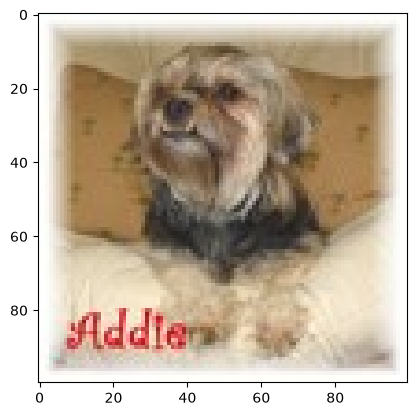

In [6]:
idx = random.randint(0, len(X_train)) 
plt.imshow(X_train[idx, :])
plt.show()

In [7]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.5245 - loss: 0.7342 - val_accuracy: 0.6225 - val_loss: 0.6840
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.5695 - loss: 0.6821 - val_accuracy: 0.5050 - val_loss: 0.6870
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.5535 - loss: 0.6765 - val_accuracy: 0.6350 - val_loss: 0.6667
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6755 - loss: 0.6186 - val_accuracy: 0.6000 - val_loss: 0.6672
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.7030 - loss: 0.5593 - val_accuracy: 0.6650 - val_loss: 0.6127
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7685 - loss: 0.4916 - val_accuracy: 0.6975 - val_loss: 0.5801
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.8105 - loss: 0.4307 - val_accuracy: 0.6650 - val_loss: 0.5980
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.8100 - loss: 0.4175 - val_accuracy: 0.6850 -

In [10]:
model.evaluate(X_test, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6975 - loss: 0.6123


[0.61234450340271, 0.6974999904632568]

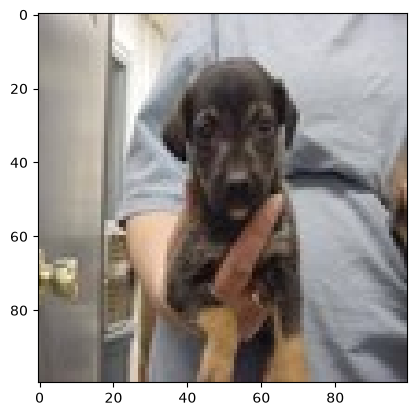

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Our model says it is a: dog


In [11]:
idx2 = random.randint(0, len(Y_test))

plt.imshow(X_test[idx2, :])
plt.show()
y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))

y_pred = y_pred > 0.5

if (y_pred == 0):
    pred = "dog"
else:
    pred = "cat"

print("Our model says it is a:", pred)

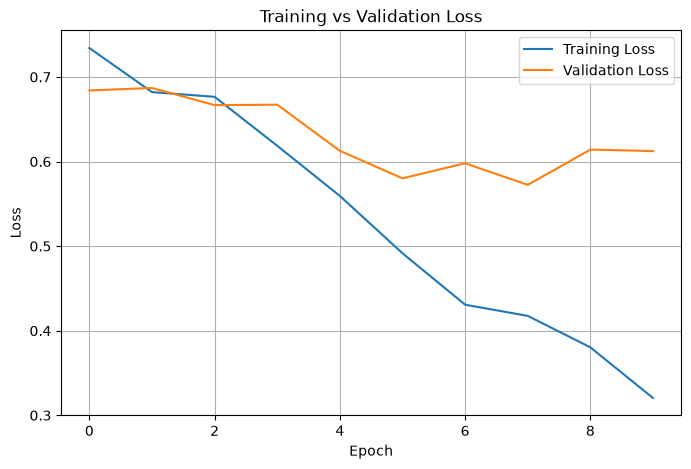

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

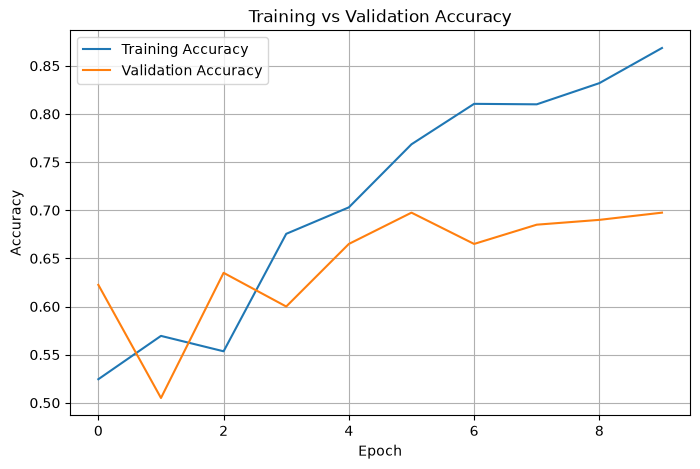

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7100 - loss: 0.6975
Test Loss: 0.697549045085907
Test Accuracy: 70.99999785423279
